In [30]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl
import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import datetime

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP, _format_fly_str 
from TB.IRSwapsTB import IRSwapsTB 

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

In [32]:
mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
tb = IRSwapsTB(mdp=mdp)

# Simple MtM

BACKTESTING...: 100%|██████████| 127/127 [00:09<00:00, 13.92step/s]


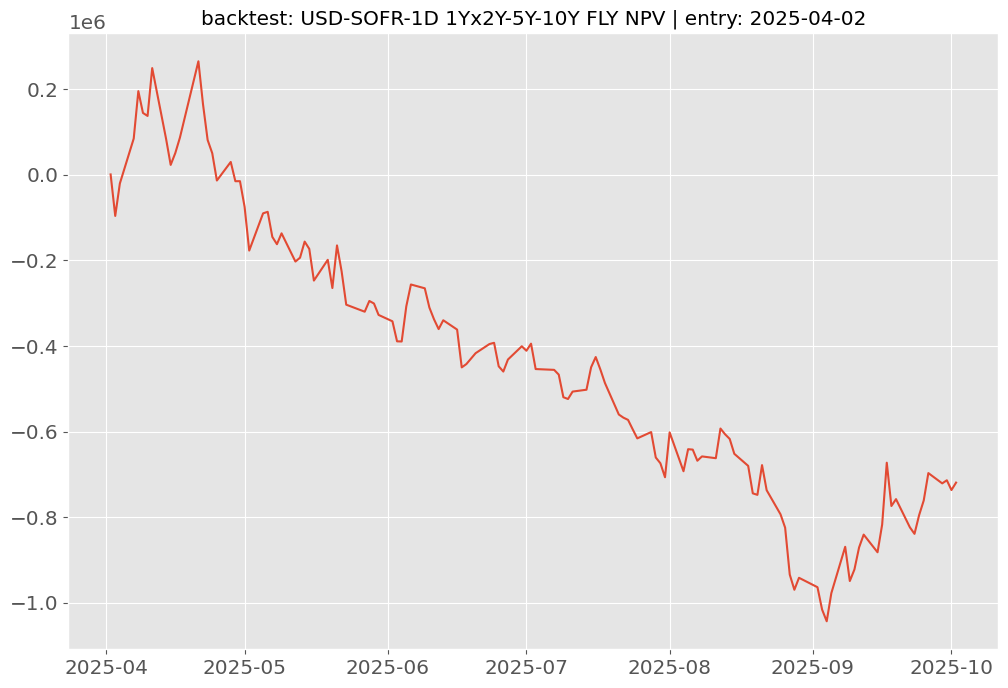

In [47]:
trade_date = datetime.date(2025, 4, 2)

fly = "1y2y/1y5y/1y10y"
risk = -100_000
query = IRSwapQuery(
    value=IRSwapValue.NPV,
    structure=IRSwapStructure.FLY,
    curve="USD-SOFR-1D",
    structure_kwargs={"front_tenor": _format_fly_str(fly)[0], "belly_tenor": _format_fly_str(fly)[1], "back_tenor": _format_fly_str(fly)[2], "bpv": risk},
)
# query = IRSwapQuery(
#     structure=IRSwapStructure.OUTRIGHT,
#     value=IRSwapValue.NPV,
#     curve="USD-SOFR-1D",
# 	tenor="10Y",
#     structure_kwargs={"bpv": 100_000},
# )
# query = IRSwapQuery(
#     structure=IRSwapStructure.CURVE,
#     value=IRSwapValue.NPV,
#     curve="USD-SOFR-1D",
#     structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": 100_000},
# )


entry = DateTrigger(DateTriggerRequirements(dates=[trade_date]), actions=[AddQueryAction(query=query)])
# exit_ = DateTrigger(DateTriggerRequirements(dates=[datetime.date(2025, 9, 15)]), actions=[UnwindPositionsAction(match_all=True, fee=0.0)])

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        start=trade_date,
        end=datetime.date(2025, 10, 2),
    )
)
strategy = QueryStrategy(name=f"{query.col_name()}", triggers=[entry])
bt = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=strategy)
bt.run()

mtm = pd.Series(bt.mtm_history).sort_index()
plt.figure()
plt.plot(mtm)
plt.title(f"backtest: {query.col_name()} | entry: {trade_date}")
plt.show()

,USD-SOFR-1D 2Y-5Y-10Y FLY RATE
Date,
2025-09-02,-40.572699
2025-09-03,-41.016683
2025-09-04,-41.459876
2025-09-05,-38.848477
2025-09-08,-36.484008
2025-09-09,-37.877030
2025-09-10,-36.453759
2025-09-11,-33.977557
2025-09-12,-33.204252


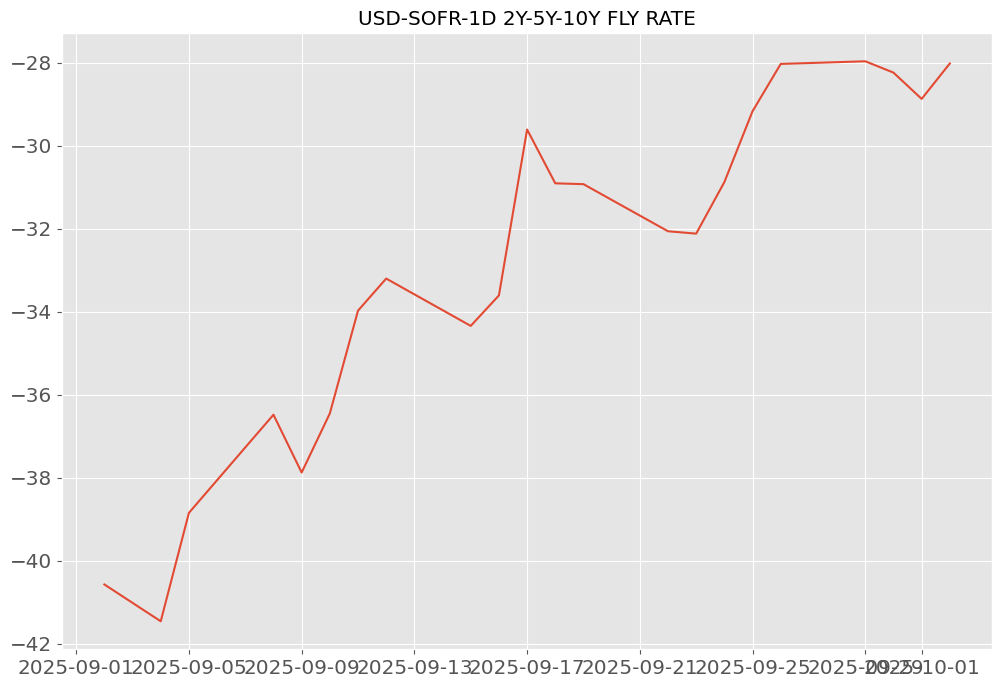

In [45]:
# fly = "1y2y/1y5y/1y10y"
fly = "2y/5y/10y"
query = IRSwapQuery(
    curve="USD-SOFR-1D",
    structure=IRSwapStructure.FLY,
    structure_kwargs={"front_tenor": _format_fly_str(fly)[0], "belly_tenor": _format_fly_str(fly)[1], "back_tenor": _format_fly_str(fly)[2], "bpv": 1},
)
# query = IRSwapQuery(
#     structure=IRSwapStructure.OUTRIGHT,
#     curve="USD-SOFR-1D",
# 	tenor="10Y",
#     structure_kwargs={"bpv": 1},
# )
# query = IRSwapQuery(
#     structure=IRSwapStructure.CURVE,
#     curve="USD-SOFR-1D",
#     structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": -100_000},
# )

df = tb.get_timeseries(start=datetime.date(2025, 9, 2), end=datetime.date(2025, 10, 2), queries=[query], n_jobs=1)
display(df)

plt.figure()
plt.plot(df.index, df[query.col_name()])
plt.title(query.col_name())
plt.show()

In [102]:
fly = "2y/5y/10y"
risk = -100_000

# q = IRSwapQuery(
#     curve="USD-SOFR-1D",
#     structure=IRSwapStructure.FLY,
#     structure_kwargs={"front_tenor": _format_fly_str(fly)[0], "belly_tenor": _format_fly_str(fly)[1], "back_tenor": _format_fly_str(fly)[2], "bpv": risk},
# )
q = IRSwapQuery(
    structure=IRSwapStructure.OUTRIGHT,
    curve="USD-SOFR-1D",
	tenor="10Y",
    structure_kwargs={"bpv": risk},
)
curve_handle = mdp._get_curve(curve_name=q.curve, timestamp=datetime.date(2025, 9, 2))
pkg, rws = q.resolve_package(pricer_or_curve=curve_handle)

vmap = q.build_value_map(pricer_or_curve=curve_handle, package=pkg, risk_weights=rws)
vmap.apply(value=IRSwapValue.RATE)

3.7399070402754635

In [61]:
vmap.apply(value=IRSwapValue.CARRY_AND_ROLL_BPS_RUNNING, **{"horizon": "1m"})

1.3515747462507917

In [103]:
pkg[0].fixedLegBPS()

-99999.99999999999